# Radar plots

Single notebook for **all KGs and all figures** — DL1, DL1 by relation type,
DL2, DL3, and Random-split vs Cold-start. **Pick the KG in the config cell
below**, then *Run All*.

All reusable code lives in `radar_plots.py`; all KG-specific settings (paths,
relations, **model list**, `y_lim`) live in `kg_configs.py`.

Figures produced:
1. **DL1** - With / Without DL1 (Global, Redundant, Indication)
2. **DL1 by relation type** - per-relation-type breakdown (KG-specific)
3. **DL2** - Unpermuted / Permuted indication (Indication, Global)
4. **DL3** - Test vs Independent test set + Indication by entity frequency
5. **Random split vs Cold-start** - Test & Independent-test MRR


In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import radar_plots as rp
import kg_configs

# Re-read radar_plots.py and kg_configs.py from disk on every run, so your edits
# (model_order, model_labels, y_lim, ...) are picked up WITHOUT restarting the
# kernel. Just re-run this cell after editing, then re-run the figure cells.
importlib.reload(rp)
importlib.reload(kg_configs)

# ===> PICK THE KG HERE: 'biokg' | 'hetionetkg' | 'shepherdkg' <===
KG = "shepherdkg"

cfg = kg_configs.CONFIGS[KG]   # access via the module so the reload is reflected
print(f"KG = {cfg.name}  |  figures -> {cfg.figures_dir}")
print("model_labels:", cfg.model_labels)   # sanity check: should show your renames

KG = shepkg  |  figures -> /home/galadriel/dr_benchmark/Figures/ShepherdKG
model_labels: {'GAT_RESCAL': 'GAT', 'GCN_RESCAL_maxIntra': 'GCNmax', 'GCN_RESCAL': 'GCNmean'}


In [2]:
# Load the metrics (DL1 / DL2 / zero-shot). 'best' = max over run1/run2.
results = rp.parse_model_metrics(cfg.dl_experiments, cfg)

# Sanity check: models found, in display order (per-KG cfg.model_order).
models = rp.order_models(results["without_dl1"]["best"], cfg.model_order)

print(f"{len(models)} models:", models)

10 models: ['GAT_RESCAL', 'GCN_RESCAL', 'GCN_RESCAL_maxIntra', 'ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']


## Figure 1.1 - DL1: With vs Without DL1

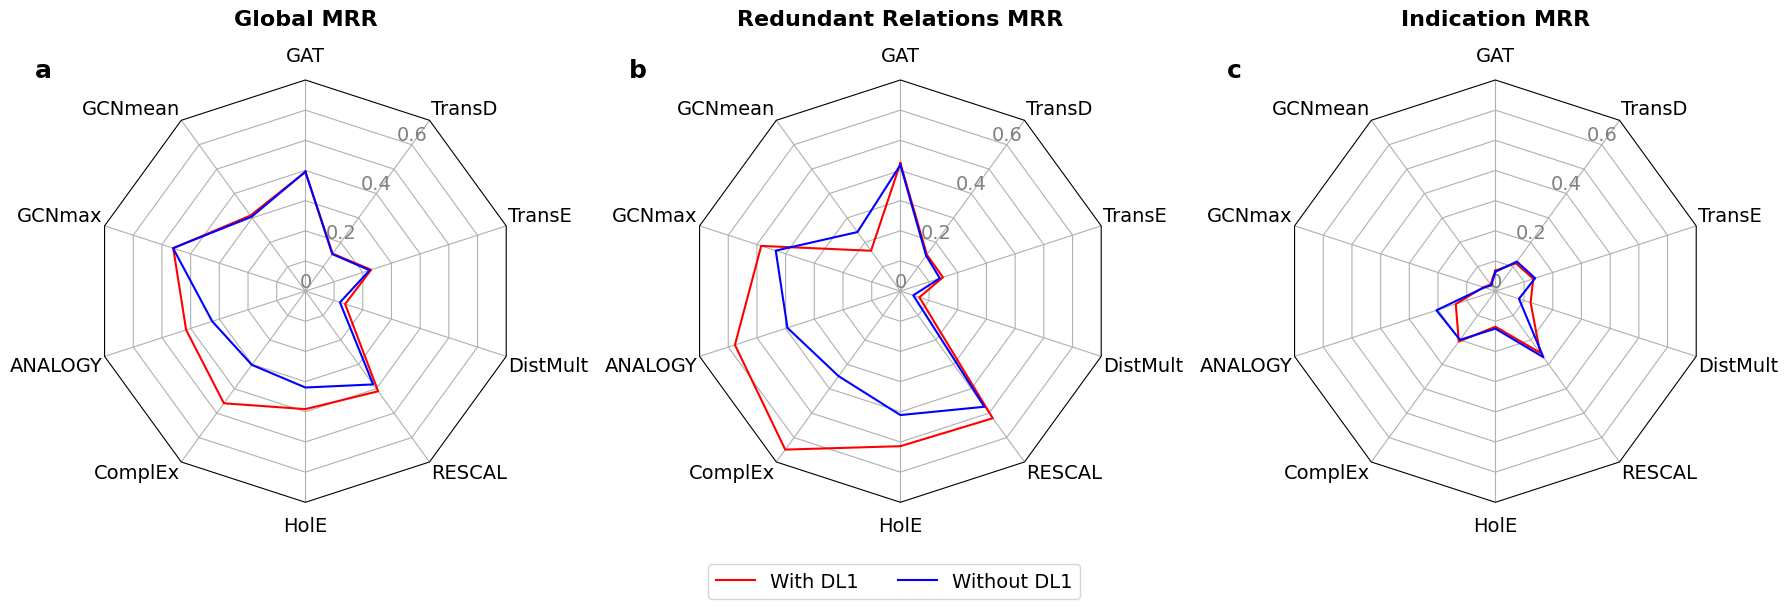

In [ ]:
rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection="radar"))

panels = [
    ("Global MRR",              "global_mrr"),
    ("Redundant Relations MRR", "made_directed_relations"),
    ("Indication MRR",          "target_relations"),
]
for i, (title, metric) in enumerate(panels):
    rp.plot_radar(
        results, experiment1="with_dl1", experiment2="without_dl1", run="best",
        metric1=metric, y_lim=cfg.ylims["fig1"], rgrid_labels=cfg.rlabels_for("fig1"), title=title,
        legend_labels=["With DL1", "Without DL1"], colors=("red", "blue"),
        model_order=cfg.model_order,
        model_labels=cfg.model_labels,
        show_legend=False,
        show=False, ax=axs[i], panel_label=chr(97 + i),
    )
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=14,
           bbox_to_anchor=(0.5, -0.06))
fig.subplots_adjust(left=0.06, right=0.94, top=0.88, bottom=0.12, wspace=0.45)

plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/DL1_{cfg.name}.pdf", bbox_inches="tight")
plt.show()

## Figure 1.2 - DL1 by relation type (made-directed breakdown)

Same With / Without DL1 comparison as Figure 1, broken down per relation type.
The number of panels and the relation types depend on the KG
(see `cfg.directed_relations` in `kg_configs.py`).

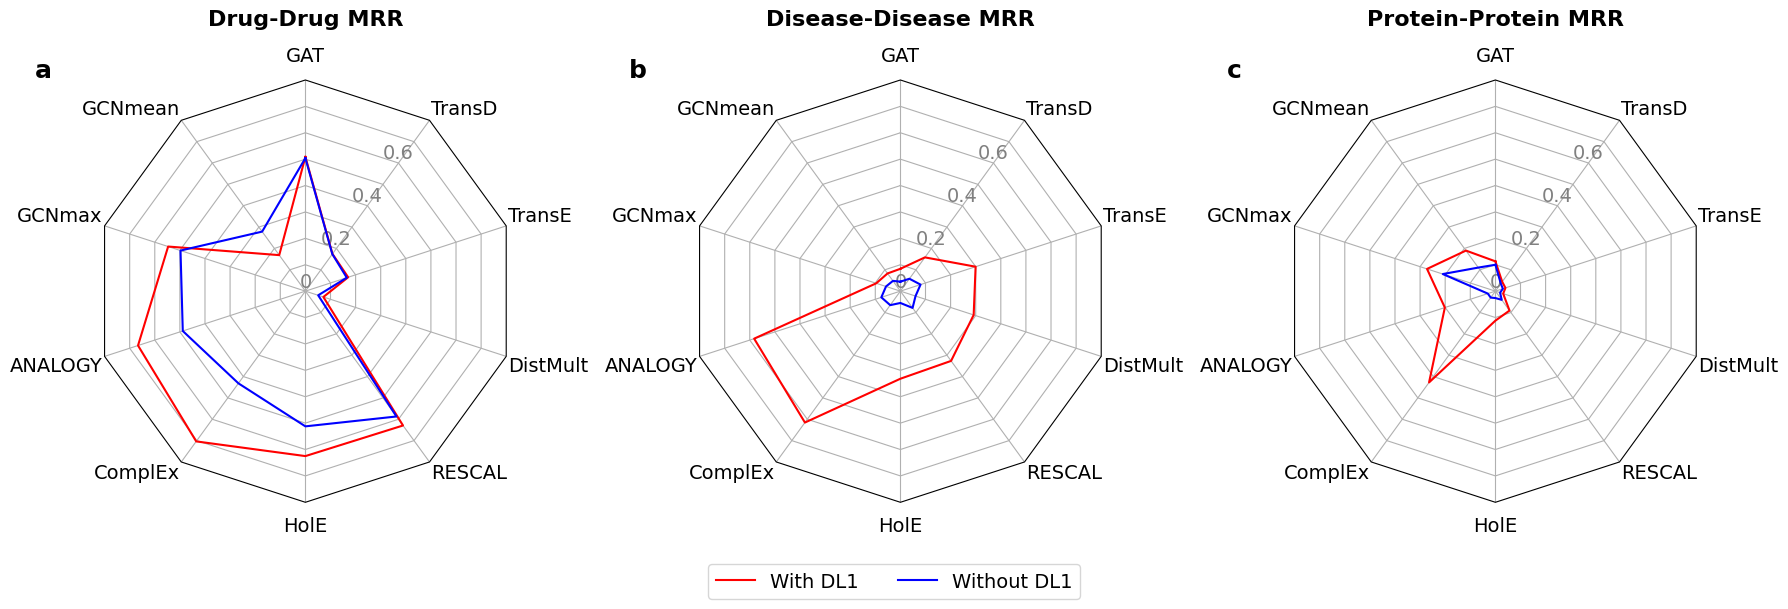

In [ ]:
dr = cfg.directed_relations           # ordered dict: metric -> {keys, title}
metrics = list(dr.keys())

rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 6),
                        subplot_kw=dict(projection="radar"))
axs = np.atleast_1d(axs)

for i, metric in enumerate(metrics):
    rp.plot_radar(
        results, experiment1="with_dl1", experiment2="without_dl1", run="best",
        metric1=metric, y_lim=cfg.ylims["directed"], rgrid_labels=cfg.rlabels_for("directed"), title=dr[metric]["title"],
        legend_labels=["With DL1", "Without DL1"], colors=("red", "blue"),
        model_order=cfg.model_order,
        model_labels=cfg.model_labels,
        show_legend=False,
        show=False, ax=axs[i], panel_label=chr(97 + i),
    )
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=14,
           bbox_to_anchor=(0.5, -0.06))
fig.subplots_adjust(left=0.06, right=0.94, top=0.88, bottom=0.12, wspace=0.45)
plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/{cfg.name}_directed_relations.pdf", bbox_inches="tight")
plt.show()

## Figure 2 - DL2: Unpermuted vs Permuted indication

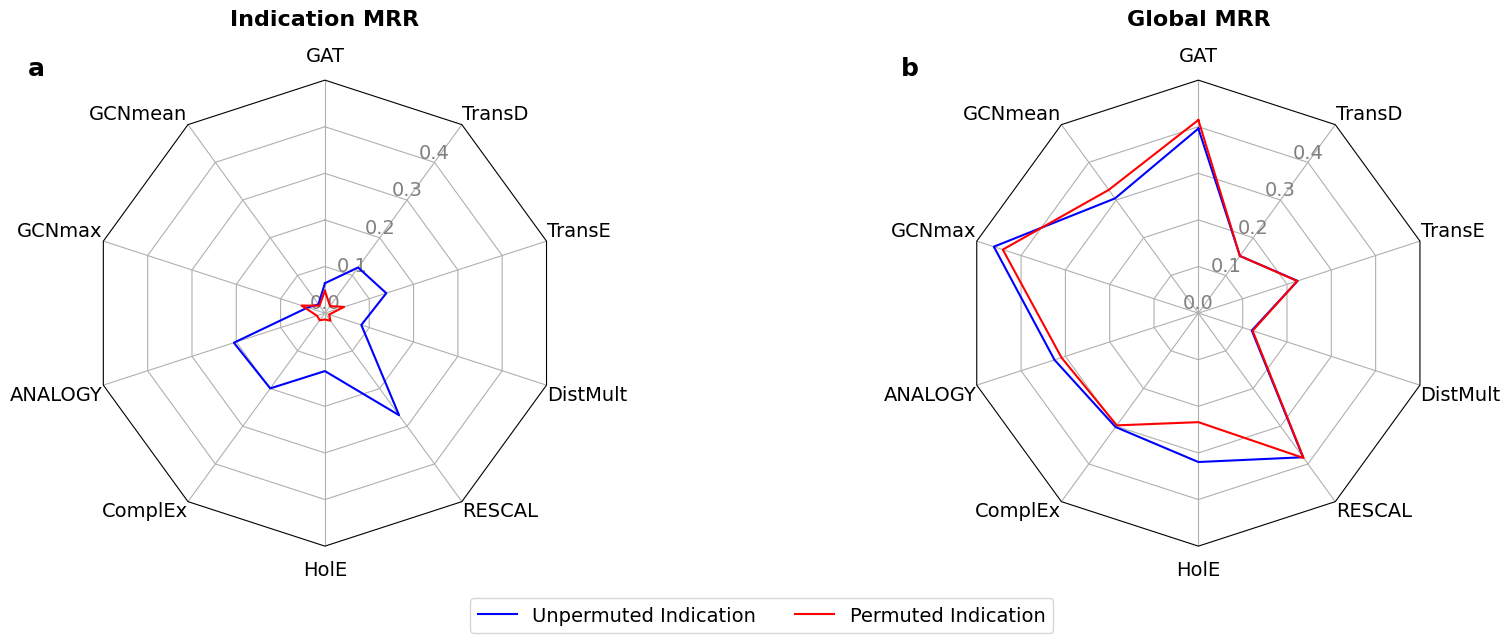

In [ ]:
rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, 2, figsize=(18, 6), subplot_kw=dict(projection="radar"))

panels = [
    ("Indication MRR", "target_relations"),
    ("Global MRR",     "global_mrr"),
]
for i, (title, metric) in enumerate(panels):
    rp.plot_radar(
        results, experiment1="without_dl1", experiment2="dl2", run="best",
        metric1=metric, y_lim=cfg.ylims["fig2"], rgrid_labels=cfg.rlabels_for("fig2"), title=title,
        legend_labels=["Unpermuted Indication", "Permuted Indication"],
        colors=("blue", "red"),
        model_order=cfg.model_order,
        model_labels=cfg.model_labels,
        show_legend=False,
        show=False, ax=axs[i], panel_label=chr(97 + i),
    )

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=14,
           bbox_to_anchor=(0.5, -0.08))
fig.subplots_adjust(left=0.06, right=0.94, top=0.88, bottom=0.12, wspace=0.45)
plt.tight_layout()
plt.savefig(f"{cfg.figures_dir}/DL2_{cfg.name}.pdf", bbox_inches="tight")
plt.show()

## Figure 3 - DL3: test vs independent test set, and by indication frequency

(Panel labels 'a' / 'c' reproduce the figure numbering from the paper.)

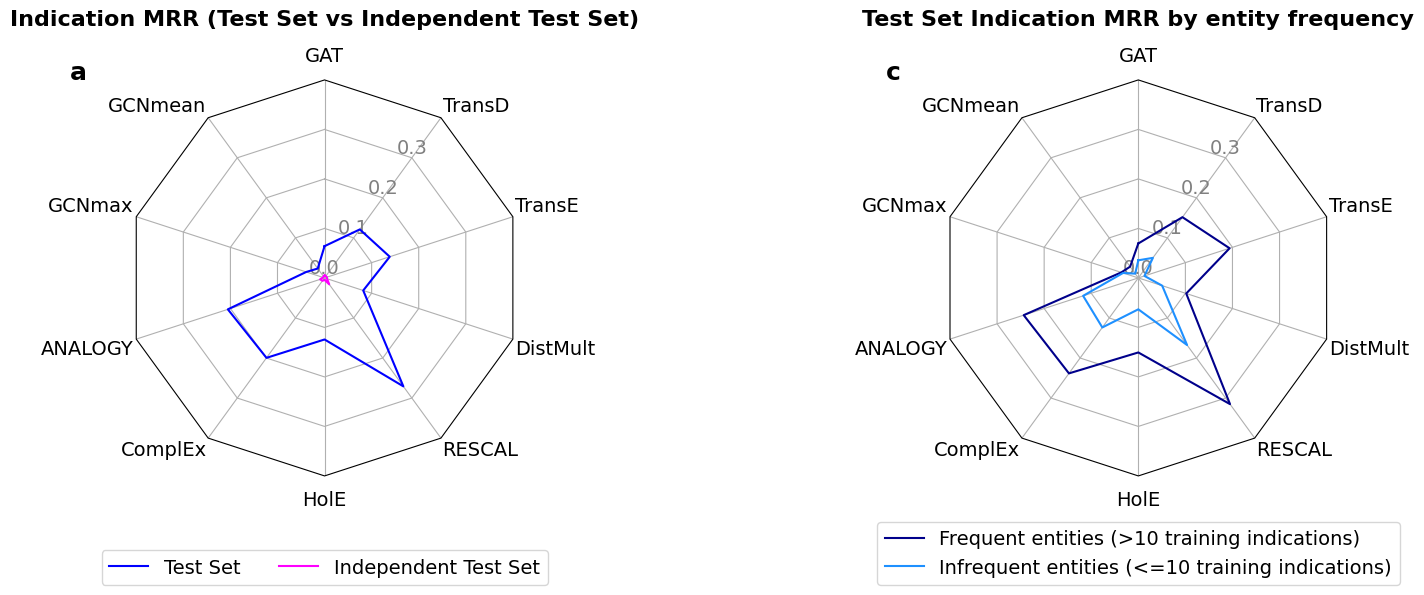

In [6]:
rp.radar_factory(len(models), frame="polygon")
fig, axs = plt.subplots(1, 2, figsize=(18, 6), subplot_kw=dict(projection="radar"))

rp.plot_radar(
    results, experiment1="without_dl1", run="best",
    metric1="target_relations", metric2="inference_mrr",
    y_lim=cfg.ylims["fig3_test_vs_inf"], rgrid_labels=cfg.rlabels_for("fig3_test_vs_inf"),
    title="Indication MRR (Test Set vs Independent Test Set)",
    legend_labels=["Test Set", "Independent Test Set"],
    colors=("blue", "fuchsia"),
    model_order=cfg.model_order, model_labels=cfg.model_labels,
    show=False, ax=axs[0], panel_label="a",
    legend_anchor=(0.5, -0.3),        
)
rp.plot_radar(
    results, experiment1="without_dl1", run="best",
    metric1="target_frequent", metric2="target_infrequent",
    y_lim=cfg.ylims["fig3_freq"], rgrid_labels=cfg.rlabels_for("fig3_freq"),
    title="Test Set Indication MRR by entity frequency",
    legend_labels=["Frequent entities (>10 training indications)",
                   "Infrequent entities (<=10 training indications)"],
    colors=("darkblue", "dodgerblue"),
    model_order=cfg.model_order, model_labels=cfg.model_labels,
    show=False, ax=axs[1], panel_label="c", legend_ncol=1,
    legend_anchor=(0.5, -0.3),         
)

fig.subplots_adjust(bottom=0.22, wspace=0.4)  
plt.savefig(f"{cfg.figures_dir}/DL3_{cfg.name}.pdf", bbox_inches="tight")
plt.show()

---
## Random split vs Cold-start

Uses a **different** set of experiments (`cfg.coldstart_experiments`), so it
gets its own `results_cs`. Compares *Random Split* / *Cold-Start Drugs* /
*Cold-Start Diseases* over two panels (Test MRR and Independent-test MRR).

In [7]:
# Random split vs cold-start uses a different set of experiments.
results_cs = rp.parse_model_metrics(cfg.coldstart_experiments, cfg)

# Sanity check
for exp in results_cs:
    print(exp, "-> best models:",
          rp.order_models(results_cs[exp]["best"], cfg.model_order, verbose=False))

random_split -> best models: ['GAT_RESCAL', 'GCN_RESCAL', 'GCN_RESCAL_maxIntra', 'ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']
cold_start_drugs -> best models: ['GAT_RESCAL', 'GCN_RESCAL', 'GCN_RESCAL_maxIntra', 'ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']
cold_start_diseases -> best models: ['GAT_RESCAL', 'GCN_RESCAL', 'GCN_RESCAL_maxIntra', 'ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']


### Figure 4 - Random split vs Cold-start (two panels)

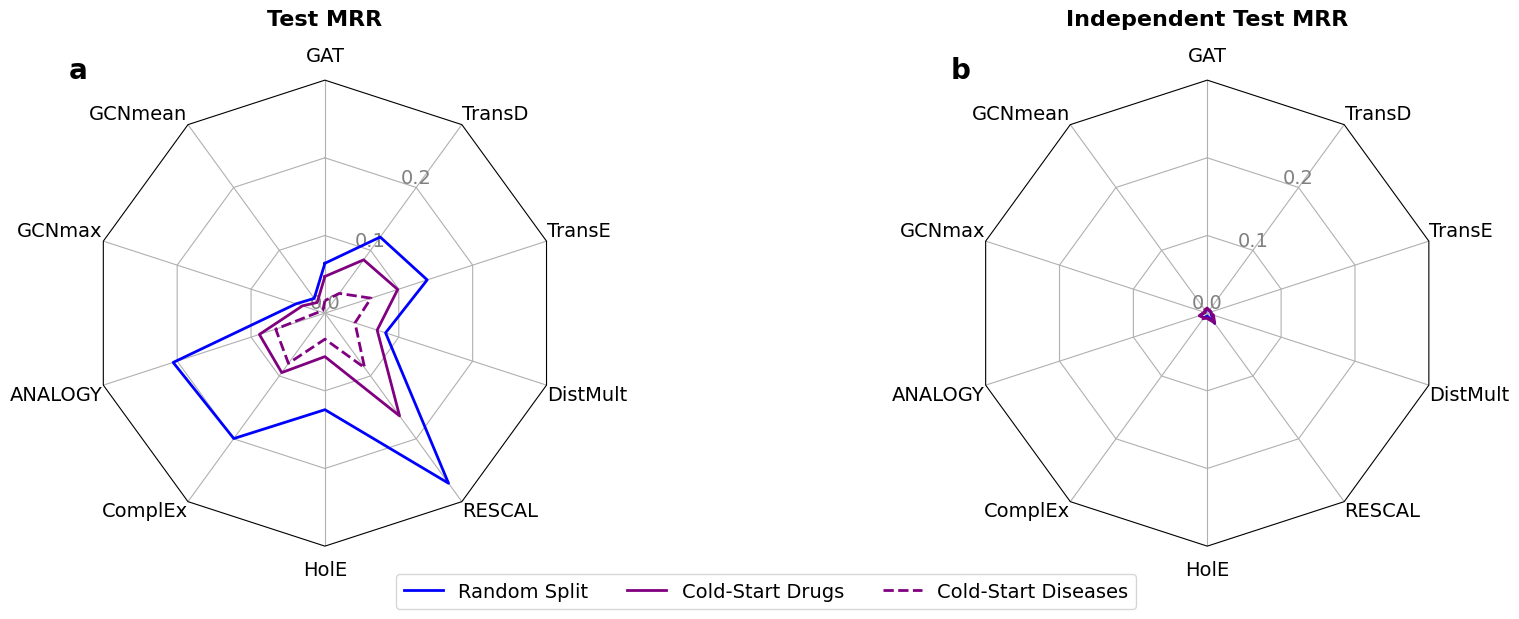

In [ ]:
experiments = ["random_split", "cold_start_drugs", "cold_start_diseases"]
labels      = ["Random Split", "Cold-Start Drugs", "Cold-Start Diseases"]
colors      = ["blue", "purple", "purple"]
linestyles  = ["-", "-", "--"]
run         = "best"
y_lim       = cfg.ylims["coldstart"]

models_cs = rp.order_models(results_cs[experiments[0]][run], cfg.model_order, verbose=False)
rp.radar_factory(len(models_cs), frame="polygon")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), subplot_kw=dict(projection="radar"))

rp.plot_radar_3way(results_cs, experiments, run, metric="target_relations",
                   legend_labels=labels, colors=colors, linestyles=linestyles,
                   model_order=cfg.model_order, y_lim=y_lim,
                   rgrid_labels=cfg.rlabels_for("coldstart"),
                   model_labels=cfg.model_labels,
                   title="Test MRR", panel_label="a", ax=axes[0])

rp.plot_radar_3way(results_cs, experiments, run, metric="inference_mrr",
                   legend_labels=labels, colors=colors, linestyles=linestyles,
                   model_order=cfg.model_order, y_lim=y_lim,
                   rgrid_labels=cfg.rlabels_for("coldstart"),
                   model_labels=cfg.model_labels,
                   title="Independent Test MRR", panel_label="b", ax=axes[1])

# Shared legend at the bottom
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=3, fontsize=14, frameon=True)

fig.tight_layout()
fig.savefig(f"{cfg.figures_dir}/radar_random_vs_coldstart_{cfg.name}.pdf", bbox_inches="tight")
plt.show()